# Spatial Batching Visualization

Visualizes how the KD-tree recursive bisection spatial batching assigns
DRB HRU polygons to batches for memory-efficient raster processing.

The pipeline processes the full target fabric (no domain bbox filter),
so batching operates on all 765 HRUs.

In [ ]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt

from hydro_param.batching import spatial_batch


In [ ]:
# Load fabric (full extent — no domain filter, matching pipeline default)
gdf = gpd.read_file("../data/pywatershed_gis/drb_2yr/nhru.gpkg")
print(f"Fabric: {len(gdf)} features, CRS={gdf.crs}")


Fabric: 765 features, CRS=EPSG:5070


In [ ]:
# Apply spatial batching with batch_size=80
batched = spatial_batch(gdf, batch_size=80)
n_batches = batched["batch_id"].nunique()
print(f"Batches: {n_batches}")
print(batched.groupby("batch_id").size().rename("count"))


Batches: 16
batch_id
0     48
1     48
2     48
3     48
4     48
5     48
6     48
7     47
8     48
9     48
10    48
11    47
12    48
13    48
14    48
15    47
Name: count, dtype: int64


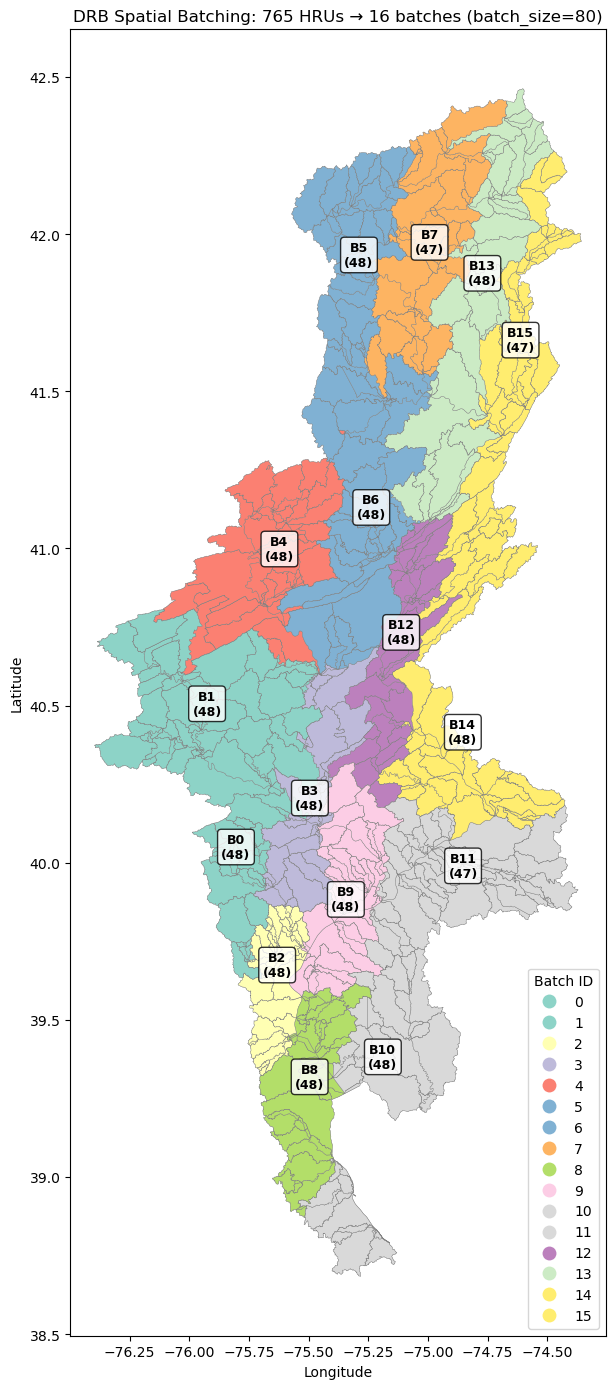

In [4]:
# Plot in WGS84
batched_4326 = batched.to_crs("EPSG:4326")

fig, ax = plt.subplots(1, 1, figsize=(10, 14))
batched_4326.plot(
    column="batch_id",
    categorical=True,
    cmap="Set3",
    edgecolor="gray",
    linewidth=0.3,
    legend=True,
    legend_kwds={"title": "Batch ID", "loc": "lower right"},
    ax=ax,
)

# Add batch labels at centroid of each group
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*geographic CRS.*centroid.*")
    for batch_id in sorted(batched_4326["batch_id"].unique()):
        group = batched_4326[batched_4326["batch_id"] == batch_id]
        cx = group.geometry.centroid.x.mean()
        cy = group.geometry.centroid.y.mean()
        count = len(group)
        ax.annotate(
            f"B{batch_id}\n({count})",
            xy=(cx, cy),
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

ax.set_title(
    f"DRB Spatial Batching: {len(batched_4326)} HRUs \u2192 {n_batches} batches (batch_size=80)"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [5]:
# Show bbox extent for each batch
from hydro_param.pipeline import _buffered_bbox

print(f"{'Batch':>5} {'Count':>5} {'West':>8} {'South':>7} {'East':>8} {'North':>7} {'dLon':>6} {'dLat':>6}")
print("-" * 60)
for batch_id in sorted(batched["batch_id"].unique()):
    group = batched[batched["batch_id"] == batch_id]
    bb = _buffered_bbox(group)
    dlon = bb[2] - bb[0]
    dlat = bb[3] - bb[1]
    print(f"{batch_id:>5} {len(group):>5} {bb[0]:>8.3f} {bb[1]:>7.3f} {bb[2]:>8.3f} {bb[3]:>7.3f} {dlon:>6.3f} {dlat:>6.3f}")


Batch Count     West   South     East   North   dLon   dLat
------------------------------------------------------------
    0    48  -76.415  39.613  -75.483  40.426  0.932  0.813
    1    48  -76.405  40.229  -75.422  40.819  0.983  0.591
    2    48  -75.802  39.311  -75.489  39.879  0.313  0.568
    3    48  -75.742  39.824  -75.193  40.706  0.549  0.882
    4    48  -76.165  40.581  -75.328  41.392  0.838  0.811
    5    48  -75.582  41.256  -75.040  42.300  0.542  1.044
    6    48  -75.692  40.575  -74.940  41.643  0.751  1.068
    7    47  -75.280  41.459  -74.655  42.448  0.625  0.988
    8    48  -75.718  38.855  -75.226  39.632  0.491  0.777
    9    48  -75.592  39.556  -75.092  40.333  0.500  0.777
   10    48  -75.559  38.658  -74.851  39.997  0.708  1.339
   11    47  -75.217  39.785  -74.355  40.217  0.863  0.432


   12    48  -75.433  40.156  -74.844  41.131  0.588  0.975
   13    48  -75.196  41.053  -74.459  42.490  0.737  1.437
   14    48  -75.234  40.051  -74.410  41.077  0.824  1.026
   15    47  -74.972  40.951  -74.346  42.290  0.626  1.339
